# Upstream QC

Plots from the upstream pipeline outputs (mapping rates, barcode filtering, cell-filtering funnel) across the four onboarded production datasets. Reads the tidy TSVs produced by `parse_dashboard.py` and writes figures into `results/cross_production_qc/upstream/`.

Sections:

- Cell-filtering funnel (linear and log width)
- Per-lane mapping (scRNA and Guide)
- Aggregated mapping (scRNA and Guide)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Polygon

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

PROJECT_ROOT = Path('/cellar/users/aklie/projects/tf_perturb_seq')
BASE_DIR = PROJECT_ROOT / 'docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc'
MANIFEST = BASE_DIR / 'manifests' / 'manifest.tsv'
COLORS_YAML = PROJECT_ROOT / 'config' / 'colors' / 'production_TF-Perturb-seq.yaml'
OUT_DIR = BASE_DIR / 'results' / 'cross_production_qc' / 'upstream'
OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(MANIFEST, sep='\t')
with open(COLORS_YAML) as f:
    palette = yaml.safe_load(f)
colors = palette['dataset_colors']
order = palette['dataset_order']

print(f'manifest:  {len(manifest)} datasets')
print(f'output:    {OUT_DIR}')


manifest:  4 datasets
output:    /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/pipeline_qc/results/cross_production_qc/upstream


In [2]:
funnel = pd.read_csv(OUT_DIR / 'filtering_funnel.tsv', sep='\t')
mapping = pd.read_csv(OUT_DIR / 'per_lane_mapping_summary.tsv', sep='\t')
print(f'funnel:    {len(funnel)} rows  ({funnel["dataset"].nunique()} datasets)')
print(f'mapping:   {len(mapping)} rows  (modalities: {sorted(mapping["modality"].unique())})')

funnel:    21 rows  (4 datasets)
mapping:   204 rows  (modalities: ['Guide', 'Hashing', 'scRNA'])


## Cell-filtering funnel

One column per dataset, each step a colored trapezoid whose width is proportional to the cell count. The linear-width version highlights how dramatically each filter cuts the cell pool; the log-width version makes late-stage stages legible when early stages dominate the count axis.

In [3]:
STAGE_LABELS = {
    'Concatenated scRNA anndata (unfiltered)': 'Concatenated\n(unfiltered)',
    'Barcode filter (knee)':  'Barcode filter\n(knee)',
    'Barcode filter (knee2)': 'Barcode filter\n(knee)',
    'Min genes per cell (>= 2500)': 'Min genes\n(≥ 2500)',
    'Intersection with hashing barcodes': 'Hashing\nintersection',
    'Demultiplex filter (HTO)': 'Demultiplex\nfilter (HTO)',
    'Intersection with guide barcodes': 'Guide\nintersection',
    'Final cells in MuData': 'Final\n(MuData)',
}

def short_stage(raw):
    if raw in STAGE_LABELS:
        return STAGE_LABELS[raw]
    if raw.startswith('Mito filter'):
        pct = raw.split('<')[-1].strip(' )%')
        try:
            return f'Mito filter\n(< {float(pct):.0f}%)'
        except ValueError:
            return 'Mito filter'
    return raw

def fmt_count(n):
    n = float(n)
    if n >= 1e9: return f'{n/1e9:.1f}B'
    if n >= 1e6:
        v = n / 1e6
        return f'{v:.1f}M' if v < 10 else f'{v:.0f}M'
    if n >= 1e3: return f'{n/1e3:.0f}K'
    return f'{int(n)}'

def draw_funnel(ax, short_name, color, stages, scale, global_max, n_stages_max):
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-(n_stages_max + 1.0) * 1.2, 0.6)
    ax.set_aspect('auto')
    ax.axis('off')
    ax.text(0, 0.25, short_name, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
    if scale == 'log':
        widths = np.log10(np.clip(stages['cells'].values, 1, None)) / np.log10(global_max)
    else:
        widths = stages['cells'].values / global_max
    widths = np.clip(widths, 0.05, 1.0)
    box_h, gap = 0.6, 0.55
    for i, (_, row) in enumerate(stages.iterrows()):
        w_top = widths[i]
        w_bot = widths[i + 1] if i + 1 < len(widths) else w_top
        y_top = -(i * (box_h + gap))
        y_bot = y_top - box_h
        ax.add_patch(Polygon(
            [(-w_top/2, y_top), (w_top/2, y_top), (w_bot/2, y_bot), (-w_bot/2, y_bot)],
            facecolor=color, edgecolor='white', linewidth=1.0, alpha=0.85,
        ))
        ax.text(0, (y_top + y_bot) / 2, fmt_count(row['cells']),
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        ax.text(0, y_bot - gap * 0.35, short_stage(row['stage']),
                ha='center', va='top', fontsize=7, color='#444')

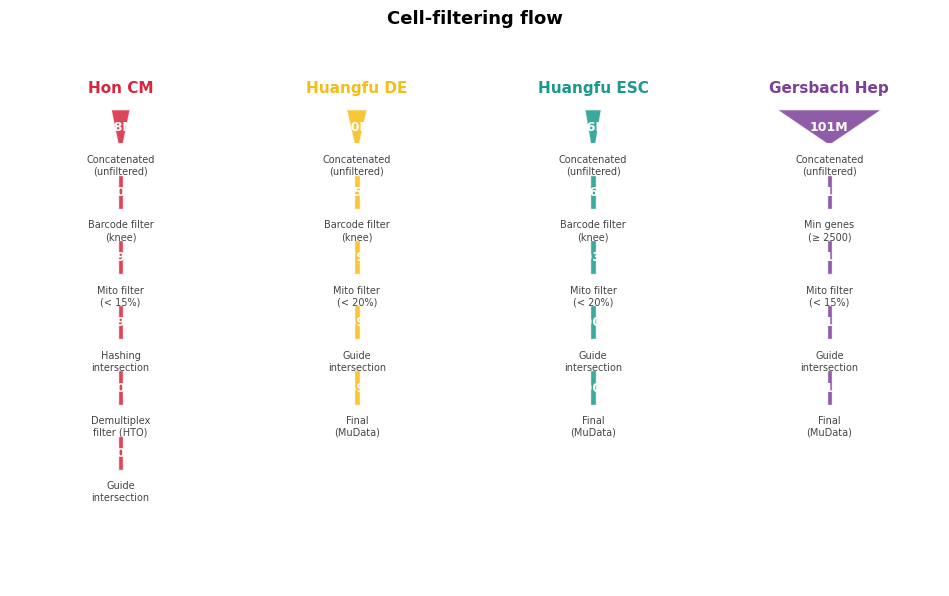

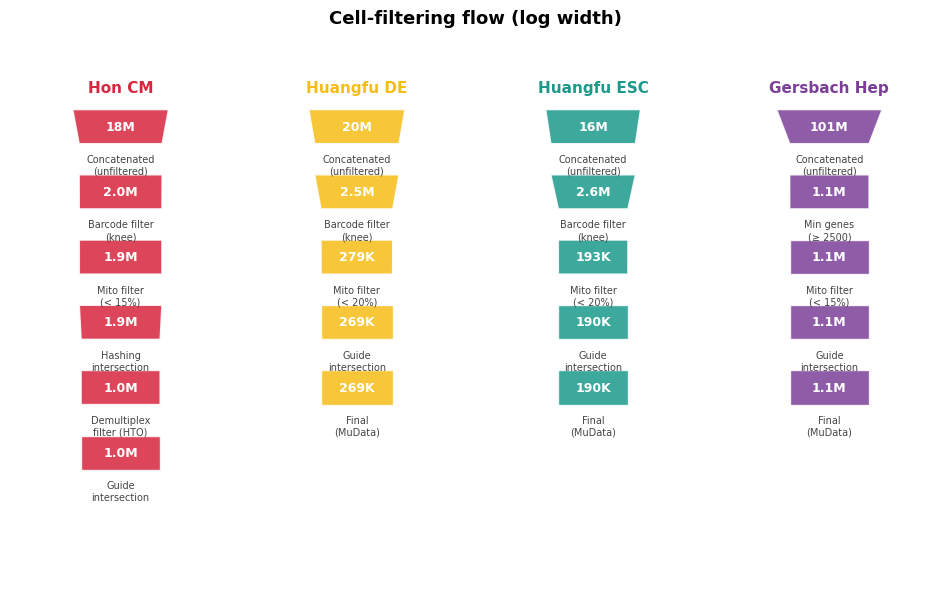

In [4]:
datasets = [d for d in order if d in funnel['dataset'].unique()]
n_datasets = len(datasets)
n_stages_max = funnel.groupby('dataset').size().max()
global_max_raw = funnel['cells'].max()

fig_w = 2.4 * n_datasets
fig_h = 0.85 * n_stages_max + 1.0

for scale in ('linear', 'log'):
    fig, axes = plt.subplots(1, n_datasets, figsize=(fig_w, fig_h), sharey=True)
    fig.suptitle('Cell-filtering flow' + (' (log width)' if scale == 'log' else ''),
                 fontsize=13, fontweight='bold', y=0.97)
    for ax, ds in zip(axes, datasets):
        stages = funnel[funnel['dataset'] == ds].sort_values('stage_index').reset_index(drop=True)
        draw_funnel(ax, stages['short_name'].iloc[0], colors[ds], stages,
                    scale, global_max_raw, n_stages_max)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    suffix = '_log' if scale == 'log' else ''
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'filtering_flow{suffix}.{ext}', dpi=200, bbox_inches='tight')
    plt.show()

## Per-lane mapping

Five panels per modality: total reads, mapped reads, alignment %, detected barcodes, % reads in onlist. One bar per measurement set, colored by dataset; lane groups are underlined and labeled by dataset. The fifth panel (% reads in onlist) is kallisto-only; for non-kallisto runs (e.g. Gersbach Hep) the bar is hatched to flag missing data.

In [5]:
PANELS = [
    ('total_reads',         'Total Reads',        'Million reads',     1e6, '{:.0f}'),
    ('paired_reads_mapped', 'Mapped Reads',       'Million reads',     1e6, '{:.0f}'),
    ('alignment_pct',       'Alignment %',        '%',                 1,   '{:.1f}'),
    ('detected_barcodes',   'Detected Barcodes',  'Thousand barcodes', 1e3, '{:.0f}'),
    ('pct_reads_in_onlist', '% Reads in Onlist',  '%',                 1,   '{:.1f}'),
]
MODALITY_TITLE = {'scRNA': 'scRNA Metrics', 'Guide': 'sgRNA Metrics', 'Hashing': 'HTO Metrics'}

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', which='both', length=0)

def plot_per_lane(modality, out_prefix):
    sub = mapping[mapping['modality'] == modality].copy()
    if sub.empty:
        print(f'  [skip] no rows for modality={modality}')
        return
    sub['__order'] = sub['dataset'].map({d: i for i, d in enumerate(order)})
    sub = sub.sort_values(['__order', 'measurement_set']).reset_index(drop=True)
    n = len(sub)
    x = np.arange(n)
    short_to_dataset = dict(zip(sub['short_name'], sub['dataset']))
    fig, axes = plt.subplots(1, len(PANELS), figsize=(4.0 * len(PANELS), 4.2))
    fig.suptitle(MODALITY_TITLE.get(modality, modality) + ' — per measurement set',
                 fontsize=13, fontweight='bold')
    for ax, (key, title, ylabel, scale, _fmt) in zip(axes, PANELS):
        vals = sub[key].astype(float) / scale
        bar_colors = [colors.get(short_to_dataset[s], '#888') for s in sub['short_name']]
        is_nan = vals.isna()
        ax.bar(x, vals.fillna(0), color=bar_colors, width=0.85, edgecolor='white', linewidth=0.5)
        if is_nan.any():
            ax.bar(x[is_nan],
                   np.full(is_nan.sum(), ax.get_ylim()[1] if not vals.dropna().empty else 1.0),
                   color='none', hatch='///', edgecolor='#bbb', linewidth=0.5, width=0.85)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_xticks([])
        style_axes(ax)
    short_arr = sub['short_name'].values
    spans = []
    for short in pd.unique(short_arr):
        positions = np.where(short_arr == short)[0]
        spans.append((short, positions[0], positions[-1], colors[short_to_dataset[short]]))
    for ax in axes:
        ax.set_xlim(-0.5, n - 0.5)
        for short, i0, i1, color in spans:
            ax.annotate('', xy=(i1 + 0.4, -0.025), xytext=(i0 - 0.4, -0.025),
                        xycoords=('data', 'axes fraction'),
                        arrowprops=dict(arrowstyle='-', color=color, lw=2.5),
                        annotation_clip=False)
            ax.annotate(short, xy=((i0 + i1) / 2, -0.055),
                        xycoords=('data', 'axes fraction'),
                        ha='right', va='top', rotation=30, rotation_mode='anchor',
                        fontsize=9, color=color, fontweight='bold', annotation_clip=False)
    plt.tight_layout(rect=(0, 0.10, 1, 0.94))
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'{out_prefix}.{ext}', dpi=200, bbox_inches='tight')
    plt.show()

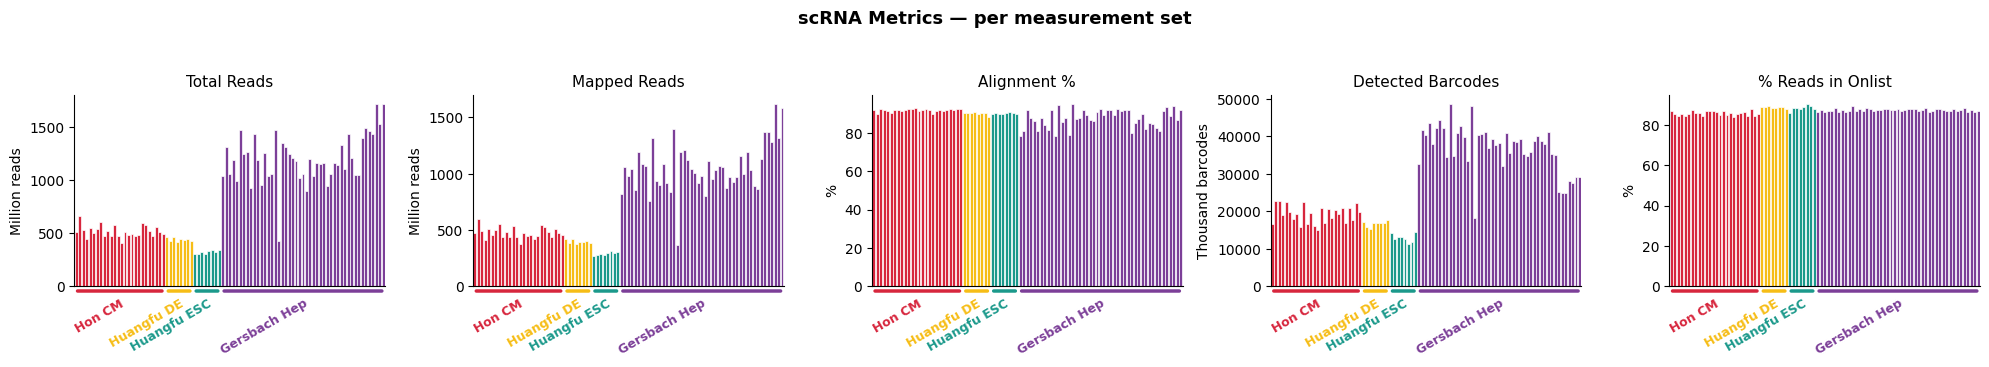

In [6]:
plot_per_lane('scRNA', 'per_lane_mapping_scrna')

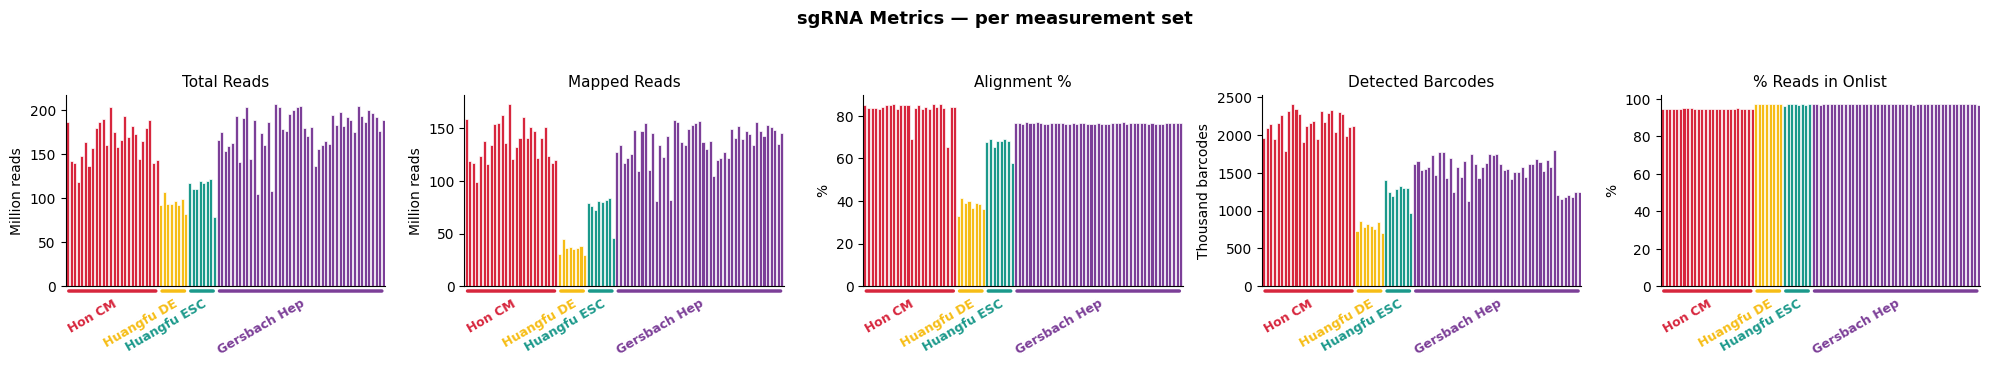

In [7]:
plot_per_lane('Guide', 'per_lane_mapping_guide')

## Aggregated mapping

Same five panels, but each dataset's measurement sets are aggregated into a single bar (sums for read/barcode counts, weighted means for alignment % and onlist %).

In [8]:
def plot_aggregated(modality, out_prefix):
    sub = mapping[mapping['modality'] == modality].copy()
    if sub.empty:
        print(f'  [skip] no rows for modality={modality}')
        return
    def _agg(group):
        total = group['total_reads'].sum()
        return pd.Series({
            'total_reads': total,
            'paired_reads_mapped': group['paired_reads_mapped'].sum(),
            'alignment_pct': 100 * group['paired_reads_mapped'].sum() / total if total else np.nan,
            'detected_barcodes': group['detected_barcodes'].sum(),
            'pct_reads_in_onlist': ((group['pct_reads_in_onlist'] * group['total_reads']).sum() / total
                                    if total and group['pct_reads_in_onlist'].notna().any() else np.nan),
        })
    agg = sub.groupby(['dataset', 'short_name'], dropna=False).apply(_agg, include_groups=False).reset_index()
    agg['__order'] = agg['dataset'].map({d: i for i, d in enumerate(order)})
    agg = agg.sort_values('__order').reset_index(drop=True)
    fig, axes = plt.subplots(1, len(PANELS), figsize=(3.0 * len(PANELS), 3.8))
    fig.suptitle(MODALITY_TITLE.get(modality, modality) + ' — aggregated across lanes',
                 fontsize=13, fontweight='bold')
    x = np.arange(len(agg))
    bar_colors = [colors.get(d, '#888') for d in agg['dataset']]
    for ax, (key, title, ylabel, scale, fmt) in zip(axes, PANELS):
        vals = agg[key].astype(float) / scale
        ax.bar(x, vals.fillna(0), color=bar_colors, width=0.7, edgecolor='white', linewidth=0.5)
        for i, (v, raw) in enumerate(zip(vals, agg[key])):
            if pd.isna(raw):
                ax.text(i, (ax.get_ylim()[1] or 1) * 0.5, 'n/a',
                        ha='center', va='center', fontsize=8, color='#999', fontweight='bold')
            else:
                ax.text(i, v, fmt.format(v), ha='center', va='bottom', fontsize=8)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(agg['short_name'], rotation=45, ha='right', fontsize=9)
        style_axes(ax)
    plt.tight_layout(rect=(0, 0, 1, 0.92))
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'{out_prefix}.{ext}', dpi=200, bbox_inches='tight')
    plt.show()

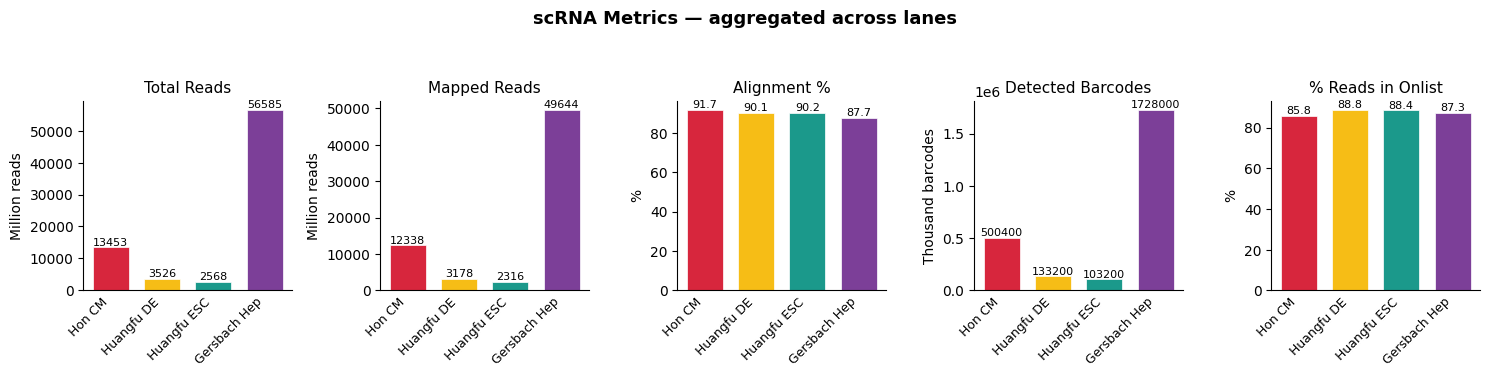

In [9]:
plot_aggregated('scRNA', 'aggregated_mapping_scrna')

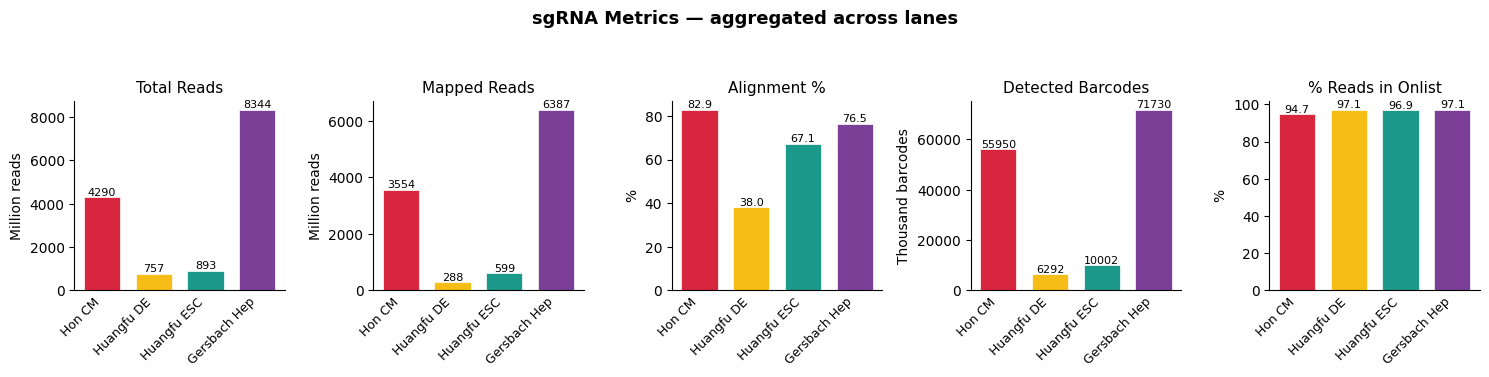

In [10]:
plot_aggregated('Guide', 'aggregated_mapping_guide')